In [13]:
# Imports & Setup 
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')


# MLP architecture 
class MLP(nn.Module):
    def __init__(self, input_dim, hidden=[128, 64, 32], num_classes=5, dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

# Load data
train_df = pd.read_csv('../data/ocpp_app_layer/Combined/Train.csv')
test_df  = pd.read_csv('../data/ocpp_app_layer/Combined/Test.csv')

label_col = 'label'
feature_cols = [c for c in train_df.columns 
                if c != label_col and train_df[c].dtype in ['float64', 'int64', 'float32', 'int32']]
print(f"Using {len(feature_cols)} numeric features")

le = LabelEncoder()
y_train = le.fit_transform(train_df[label_col])
y_test  = le.transform(test_df[label_col])

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[feature_cols].values)
X_test  = scaler.transform(test_df[feature_cols].values)

# Train fresh model
def train_model(X_tr, y_tr, input_dim, epochs=50, patience=10):
    torch.manual_seed(42)
    m = MLP(input_dim=input_dim)
    optimizer = torch.optim.Adam(m.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    X_t = torch.tensor(X_tr, dtype=torch.float32)
    y_t = torch.tensor(y_tr, dtype=torch.long)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=32, shuffle=True)
    best_loss, wait, best_state = float('inf'), 0, None
    m.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(m(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        if epoch_loss < best_loss:
            best_loss, wait = epoch_loss, 0
            best_state = {k: v.clone() for k, v in m.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break
    m.load_state_dict(best_state)
    m.eval()
    return m

print("Training model...")
model = train_model(X_train, y_train, input_dim=X_train.shape[1])

# Predict function
def predict(X_np):
    with torch.no_grad():
        logits = model(torch.tensor(X_np, dtype=torch.float32))
        probs  = torch.softmax(logits, dim=1).numpy()
        preds  = np.argmax(probs, axis=1)
    return preds, probs

# Save model for reuse in later cells
torch.save(model.state_dict(), '../outputs/mlp_final_v2.pt')

print("Done.")
print(f"Input features : {X_train.shape[1]}")
print(f"Train samples  : {X_train.shape[0]}")
print(f"Test samples   : {X_test.shape[0]}")
print(f"Classes        : {le.classes_}")

Using 51 numeric features
Training model...
  Early stopping at epoch 27
Done.
Input features : 51
Train samples  : 3020
Test samples   : 1295
Classes        : ['cyberattack_ocpp16_doc_idtag'
 'cyberattack_ocpp16_dos_flooding_heartbeat'
 'cyberattack_ocpp16_fdi_chargingprofile'
 'cyberattack_ocpp16_unauthorized_access' 'normal']


In [14]:
preds_clean, probs_clean = predict(X_test)
acc_clean = accuracy_score(y_test, preds_clean)
f1_clean  = f1_score(y_test, preds_clean, average='macro')

print(f"Clean Accuracy : {acc_clean:.4f}")
print(f"Clean Macro F1 : {f1_clean:.4f}")

Clean Accuracy : 0.9992
Clean Macro F1 : 0.9992


In [15]:
# Stress Test 1 — Gaussian Noise
results = []

for sigma in [0.1, 0.5, 1.0, 2.0]:
    np.random.seed(42)
    X_noisy = X_test + np.random.normal(0, sigma, X_test.shape)
    preds_n, _ = predict(X_noisy)
    acc = accuracy_score(y_test, preds_n)
    f1  = f1_score(y_test, preds_n, average='macro')
    results.append({'Test': f'Gaussian Noise σ={sigma}', 'Accuracy': acc, 'Macro F1': f1})
    print(f"σ={sigma:4.1f}  →  Acc={acc:.4f}  F1={f1:.4f}")

noise_results = pd.DataFrame(results)

σ= 0.1  →  Acc=0.9992  F1=0.9992
σ= 0.5  →  Acc=0.9938  F1=0.9938
σ= 1.0  →  Acc=0.9436  F1=0.9436
σ= 2.0  →  Acc=0.7699  F1=0.7707


In [16]:
# Stress Test 2 — Feature Masking
mask_results = []

for pct in [0.10, 0.25, 0.50]:
    np.random.seed(42)
    X_masked = X_test.copy()
    n_mask = int(pct * X_test.shape[1])
    mask_cols = np.random.choice(X_test.shape[1], n_mask, replace=False)
    X_masked[:, mask_cols] = 0.0   # zero-fill = mean imputation after scaling
    preds_m, _ = predict(X_masked)
    acc = accuracy_score(y_test, preds_m)
    f1  = f1_score(y_test, preds_m, average='macro')
    mask_results.append({'Test': f'Feature Masking {int(pct*100)}%', 'Accuracy': acc, 'Macro F1': f1})
    print(f"Mask {int(pct*100):3d}% features  →  Acc={acc:.4f}  F1={f1:.4f}")

mask_df = pd.DataFrame(mask_results)

Mask  10% features  →  Acc=0.9961  F1=0.9961
Mask  25% features  →  Acc=0.9985  F1=0.9985
Mask  50% features  →  Acc=0.9931  F1=0.9931


In [17]:
# Stress Test 3 — OOD Samples
np.random.seed(42)

# OOD: random uniform samples far outside the training distribution
X_ood = np.random.uniform(low=-10, high=10, size=(500, X_test.shape[1]))
preds_ood, probs_ood = predict(X_ood)

# For OOD we measure confidence (we have no true labels)
max_conf = probs_ood.max(axis=1)
print(f"OOD samples: 500")
print(f"Mean max confidence : {max_conf.mean():.4f}")
print(f"% predictions with confidence > 0.9 : {(max_conf > 0.9).mean()*100:.1f}%")
print(f"% predictions with confidence > 0.5 : {(max_conf > 0.5).mean()*100:.1f}%")
print("\nPrediction class distribution on OOD data:")
unique, counts = np.unique(preds_ood, return_counts=True)
for cls, cnt in zip(le.classes_[unique], counts):
    print(f"  {cls}: {cnt} ({cnt/500*100:.1f}%)")

OOD samples: 500
Mean max confidence : 0.9755
% predictions with confidence > 0.9 : 92.4%
% predictions with confidence > 0.5 : 100.0%

Prediction class distribution on OOD data:
  cyberattack_ocpp16_doc_idtag: 96 (19.2%)
  cyberattack_ocpp16_dos_flooding_heartbeat: 95 (19.0%)
  cyberattack_ocpp16_fdi_chargingprofile: 98 (19.6%)
  cyberattack_ocpp16_unauthorized_access: 23 (4.6%)
  normal: 188 (37.6%)


In [18]:
# Stress Test 4 — Class Rarity Scenario
# Simulate a scenario where one attack class is severely underrepresented
# in a new deployment batch (only 5 samples of that class visible)

rarity_results = []
class_names = le.classes_

for target_class_idx in range(5):
    # all samples of other classes + only 5 of target
    mask_other = y_test != target_class_idx
    mask_target = np.where(y_test == target_class_idx)[0][:5]
    
    idx_other = np.where(mask_other)[0]
    combined = np.concatenate([idx_other, mask_target])
    
    X_rare = X_test[combined]
    y_rare = y_test[combined]
    
    preds_r, _ = predict(X_rare)
    
    # Per-class recall for the rare class
    from sklearn.metrics import recall_score
    rec = recall_score(y_rare, preds_r, labels=[target_class_idx], average=None)
    f1_macro = f1_score(y_rare, preds_r, average='macro')
    
    rarity_results.append({
        'Rare Class': class_names[target_class_idx],
        'Rare Class Recall': rec[0] if len(rec) > 0 else 0.0,
        'Macro F1': f1_macro
    })
    print(f"Rare class: {class_names[target_class_idx]:40s}  Recall={rec[0] if len(rec)>0 else 0:.4f}  MacroF1={f1_macro:.4f}")

rarity_df = pd.DataFrame(rarity_results)

Rare class: cyberattack_ocpp16_doc_idtag              Recall=1.0000  MacroF1=0.9814
Rare class: cyberattack_ocpp16_dos_flooding_heartbeat  Recall=1.0000  MacroF1=0.9992
Rare class: cyberattack_ocpp16_fdi_chargingprofile    Recall=1.0000  MacroF1=0.9992
Rare class: cyberattack_ocpp16_unauthorized_access    Recall=1.0000  MacroF1=0.9992
Rare class: normal                                    Recall=1.0000  MacroF1=1.0000


In [19]:
# Full Stress Test Summary Table
import pandas as pd

baseline_row = pd.DataFrame([{
    'Test': 'Clean Baseline', 
    'Accuracy': acc_clean, 
    'Macro F1': f1_clean
}])

summary = pd.concat([baseline_row, noise_results, mask_df], ignore_index=True)
summary['Accuracy'] = summary['Accuracy'].map('{:.4f}'.format)
summary['Macro F1'] = summary['Macro F1'].map('{:.4f}'.format)

print("=" * 55)
print("STRESS TEST SUMMARY")
print("=" * 55)
print(summary.to_string(index=False))
print("=" * 55)

STRESS TEST SUMMARY
                Test Accuracy Macro F1
      Clean Baseline   0.9992   0.9992
Gaussian Noise σ=0.1   0.9992   0.9992
Gaussian Noise σ=0.5   0.9938   0.9938
Gaussian Noise σ=1.0   0.9436   0.9436
Gaussian Noise σ=2.0   0.7699   0.7707
 Feature Masking 10%   0.9961   0.9961
 Feature Masking 25%   0.9985   0.9985
 Feature Masking 50%   0.9931   0.9931


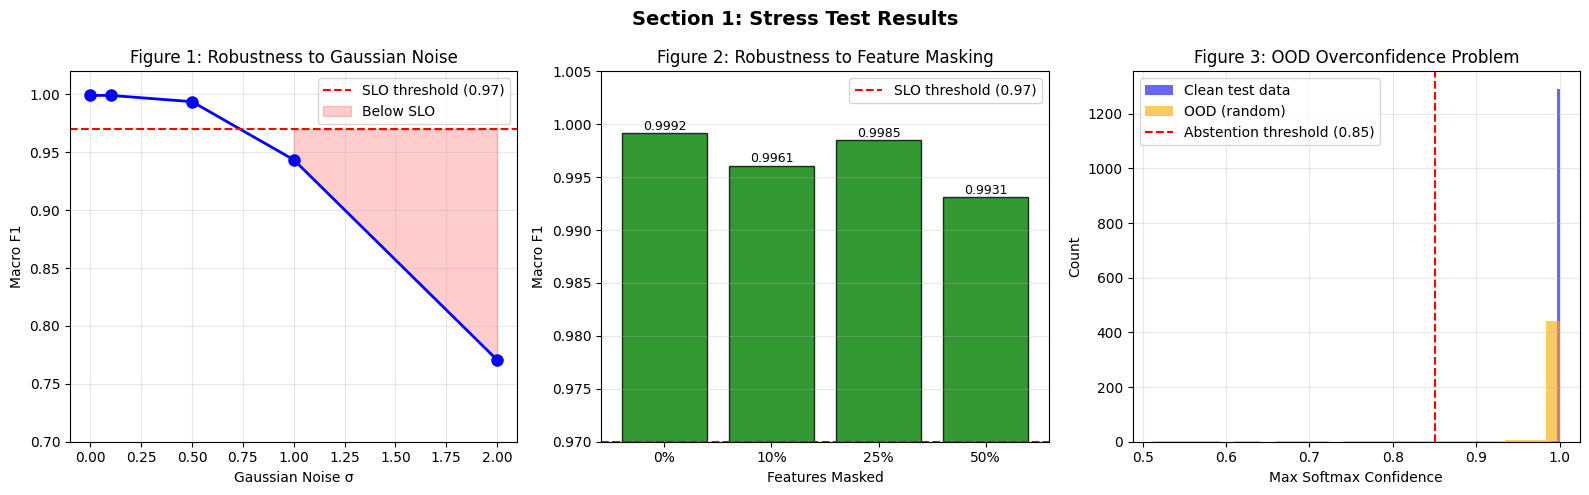

Figure saved to outputs/figures/section1_stress_tests.png


In [20]:
# Visualizations
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Section 1: Stress Test Results', fontsize=14, fontweight='bold')

# Plot 1: Noise robustness curve
sigmas = [0, 0.1, 0.5, 1.0, 2.0]
f1_noise = [0.9992, 0.9992, 0.9938, 0.9436, 0.7707]
axes[0].plot(sigmas, f1_noise, 'bo-', linewidth=2, markersize=8)
axes[0].axhline(y=0.97, color='red', linestyle='--', label='SLO threshold (0.97)')
axes[0].fill_between(sigmas, f1_noise, 0.97, where=[f < 0.97 for f in f1_noise],
                     alpha=0.2, color='red', label='Below SLO')
axes[0].set_xlabel('Gaussian Noise σ')
axes[0].set_ylabel('Macro F1')
axes[0].set_title('Figure 1: Robustness to Gaussian Noise')
axes[0].set_ylim(0.7, 1.02)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Feature masking robustness
mask_pct = [0, 10, 25, 50]
f1_mask  = [0.9992, 0.9961, 0.9985, 0.9931]
axes[1].bar([str(p)+'%' for p in mask_pct], f1_mask, 
            color=['green' if f >= 0.97 else 'red' for f in f1_mask],
            edgecolor='black', alpha=0.8)
axes[1].axhline(y=0.97, color='red', linestyle='--', label='SLO threshold (0.97)')
axes[1].set_xlabel('Features Masked')
axes[1].set_ylabel('Macro F1')
axes[1].set_title('Figure 2: Robustness to Feature Masking')
axes[1].set_ylim(0.97, 1.005)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(f1_mask):
    axes[1].text(i, v + 0.0003, f'{v:.4f}', ha='center', fontsize=9)

# Plot 3: OOD confidence histogram
np.random.seed(42)
X_ood_plot = np.random.uniform(low=-10, high=10, size=(500, X_test.shape[1]))
_, probs_ood_plot = predict(X_ood_plot)
_, probs_clean_plot = predict(X_test)
max_conf_ood   = probs_ood_plot.max(axis=1)
max_conf_clean = probs_clean_plot.max(axis=1)

axes[2].hist(max_conf_clean, bins=30, alpha=0.6, color='blue', label='Clean test data')
axes[2].hist(max_conf_ood,   bins=30, alpha=0.6, color='orange', label='OOD (random)')
axes[2].axvline(x=0.85, color='red', linestyle='--', label='Abstention threshold (0.85)')
axes[2].set_xlabel('Max Softmax Confidence')
axes[2].set_ylabel('Count')
axes[2].set_title('Figure 3: OOD Overconfidence Problem')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/section1_stress_tests.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to outputs/figures/section1_stress_tests.png")